# 🫁 End-to-End Machine Learning: Lung Cancer Survival Prediction
This notebook contains the full pipeline for predicting lung cancer patient survival beyond 5 years, utilizing **XGBoost** for classification and **Cox Proportional Hazards** for survival analysis.

## Step 3: Data Loading & Initial Inspection
First, we load our dataset and remove identifiers or timestamps that have no predictive power for biology.

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load the dataset (path is relative since we are in the notebooks/ folder)
df = pd.read_csv('../data/lung_cancer_dataset.csv')

# Drop useless features
df = df.drop(columns=['Patient_ID', 'Diagnosis_Date', 'Diagnosis_Year'])

# Display the first 5 rows
pd.set_option('display.max_columns', None) # Ensures Pandas doesn't hide columns
display(df.head())

,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Secondhand_Smoke,Family_History,Occupational_Hazard,Air_Pollution_Exposure,Alcohol_Use,BMI,Exercise_Frequency,Chronic_Lung_Disease,Asbestos_Exposure,Radon_Exposure,Previous_Cancer_History,Genetic_Mutation,Coughing,Shortness_of_Breath,Chest_Pain,Coughing_Blood,Fatigue,Weight_Loss,Wheezing,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,Western Pacific,China,46,Female,Current Smoker,28,28,Yes,No,No,Moderate,No Alcohol,29.6,Low,Yes,No,No,No,No Mutation,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No
1,Americas,Mexico,71,Male,Former Smoker,5,34,Yes,No,No,High,Heavy,31.3,Moderate,No,No,No,Yes,KRAS,Yes,Yes,No,No,Yes,No,Yes,No,Yes,No,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,Western Pacific,Japan,53,Female,Never Smoked,0,0,Yes,No,No,High,Moderate,25.8,Low,No,No,No,No,KRAS,No,No,Yes,Yes,Yes,No,No,No,No,No,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,Western Pacific,Singapore,55,Male,Current Smoker,21,34,No,Yes,No,Moderate,No Alcohol,25.3,Low,Yes,No,No,No,No Mutation,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No,No,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,Western Pacific,Malaysia,54,Male,Never Smoked,0,0,No,No,Yes,High,No Alcohol,32.0,Low,Yes,No,No,Yes,KRAS,Yes,No,Yes,No,Yes,No,Yes,No,Yes,No,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes


In [3]:
# Check for missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   WHO_Region               1500 non-null   object 
 1   Country                  1500 non-null   object 
 2   Age                      1500 non-null   int64  
 3   Gender                   1500 non-null   object 
 4   Smoking_Status           1500 non-null   object 
 5   Cigarettes_Per_Day       1500 non-null   int64  
 6   Years_Smoking            1500 non-null   int64  
 7   Secondhand_Smoke         1500 non-null   object 
 8   Family_History           1500 non-null   object 
 9   Occupational_Hazard      1500 non-null   object 
 10  Air_Pollution_Exposure   1500 non-null   object 
 11  Alcohol_Use              1500 non-null   object 
 12  BMI                      1500 non-null   float64
 13  Exercise_Frequency       1500 non-null   object 
 14  Chronic_Lung_Disease    

## Step 4: Exploratory Data Analysis (EDA)
In this step, we visualize the clinical data to understand its distribution and check for class imbalance. We will use `matplotlib` and `seaborn` to create research-quality charts.

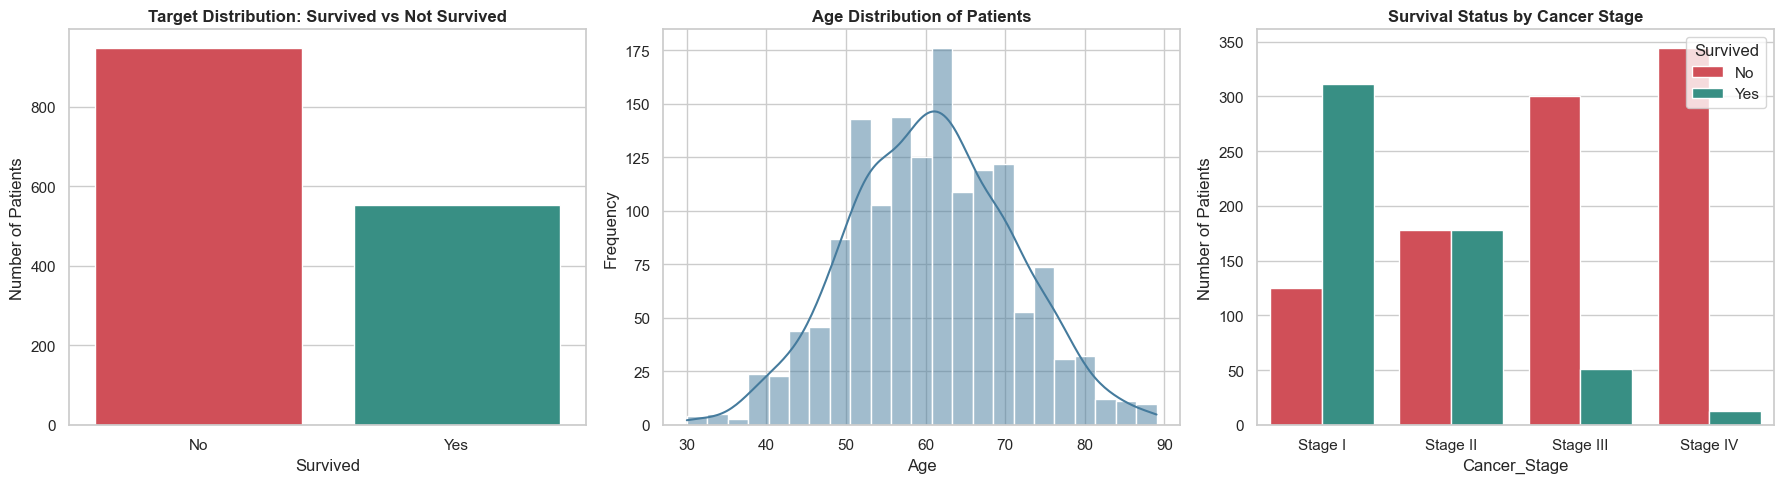

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a beautiful, professional theme for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (18, 5)})

fig, axes = plt.subplots(1, 3)

# 1. Target Distribution (Imbalance Check)
sns.countplot(data=df, x='Survived', ax=axes[0], palette=['#e63946', '#2a9d8f'])
axes[0].set_title('Target Distribution: Survived vs Not Survived', fontweight='bold')
axes[0].set_ylabel('Number of Patients')

# 2. Age Distribution
sns.histplot(data=df, x='Age', kde=True, ax=axes[1], color='#457b9d')
axes[1].set_title('Age Distribution of Patients', fontweight='bold')
axes[1].set_ylabel('Frequency')

# 3. Survival by Cancer Stage
sns.countplot(data=df, x='Cancer_Stage', hue='Survived', ax=axes[2], palette=['#e63946', '#2a9d8f'], 
              order=['Stage I', 'Stage II', 'Stage III', 'Stage IV'])
axes[2].set_title('Survival Status by Cancer Stage', fontweight='bold')
axes[2].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

## Step 5: Data Preprocessing & SMOTE
Machine learning models require numbers, not text. In this step we:
1. **Encode** ordinal categories (Cancer Stage I-IV) into numbers 1-4.
2. **One-Hot Encode** the remaining text categories.
3. **Drop Data Leakage columns** like `Survival_Months` from our training features.
4. **Apply SMOTE** to balance the dataset so our model doesn't become biased towards the majority class.

In [5]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Map 'Cancer_Stage' to numbers so the model understands severity
stage_map = {'Stage I': 1, 'Stage II': 2, 'Stage III': 3, 'Stage IV': 4}
df['Cancer_Stage'] = df['Cancer_Stage'].map(stage_map)

# Map target variable to 0 and 1
df['Survived'] = df['Survived'].map({'No': 0, 'Yes': 1})

# 2. One-Hot Encode all other text columns (Pandas does this automatically!)
# Converting string columns into numeric boolean (True/False) columns, then into integers
df_encoded = pd.get_dummies(df, drop_first=True).astype(int)

# 3. Separate features (X) and target (y)
# We drop 'Survived' (the answer) and 'Survival_Months' (the cheat code)
X = df_encoded.drop(columns=['Survived', 'Survival_Months'])
y = df_encoded['Survived']

# 4. Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("Original Data:", y.value_counts().to_dict())
print("Balanced Data:", y_balanced.value_counts().to_dict())

Original Data: {0: 947, 1: 553}
Balanced Data: {0: 947, 1: 947}


## Step 6: Model Building
We will split our balanced data into a Training Set (80%) and a Testing Set (20%). Then, we will train three different algorithms and compare their accuracy:
1. **Logistic Regression** (Baseline)
2. **Random Forest** (Ensemble)
3. **XGBoost** (Gradient Boosting)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# 2. Initialize models
log_reg = LogisticRegression(max_iter=2000, random_state=42)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 3. Train models
print("Training models...")
log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# 4. Test models
print("\n--- Model Accuracy on Unseen Patients ---")
print(f"Logistic Regression: {accuracy_score(y_test, log_reg.predict(X_test)):.1%}")
print(f"Random Forest:       {accuracy_score(y_test, rf.predict(X_test)):.1%}")
print(f"XGBoost:             {accuracy_score(y_test, xgb.predict(X_test)):.1%}")


Training models...

--- Model Accuracy on Unseen Patients ---
Logistic Regression: 79.9%
Random Forest:       81.0%
XGBoost:             82.3%


## Step 7: Model Evaluation
Accuracy isn't enough in healthcare. Here we evaluate our models using:
1. **Confusion Matrix:** To see the exact false positives and false negatives.
2. **ROC-AUC Curve:** To visualize the tradeoff between true positive rate and false positive rate.
3. **Classification Report:** To view Precision, Recall, and F1-Score.

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

        Died       0.83      0.82      0.82       190
    Survived       0.82      0.83      0.82       189

    accuracy                           0.82       379
   macro avg       0.82      0.82      0.82       379
weighted avg       0.82      0.82      0.82       379



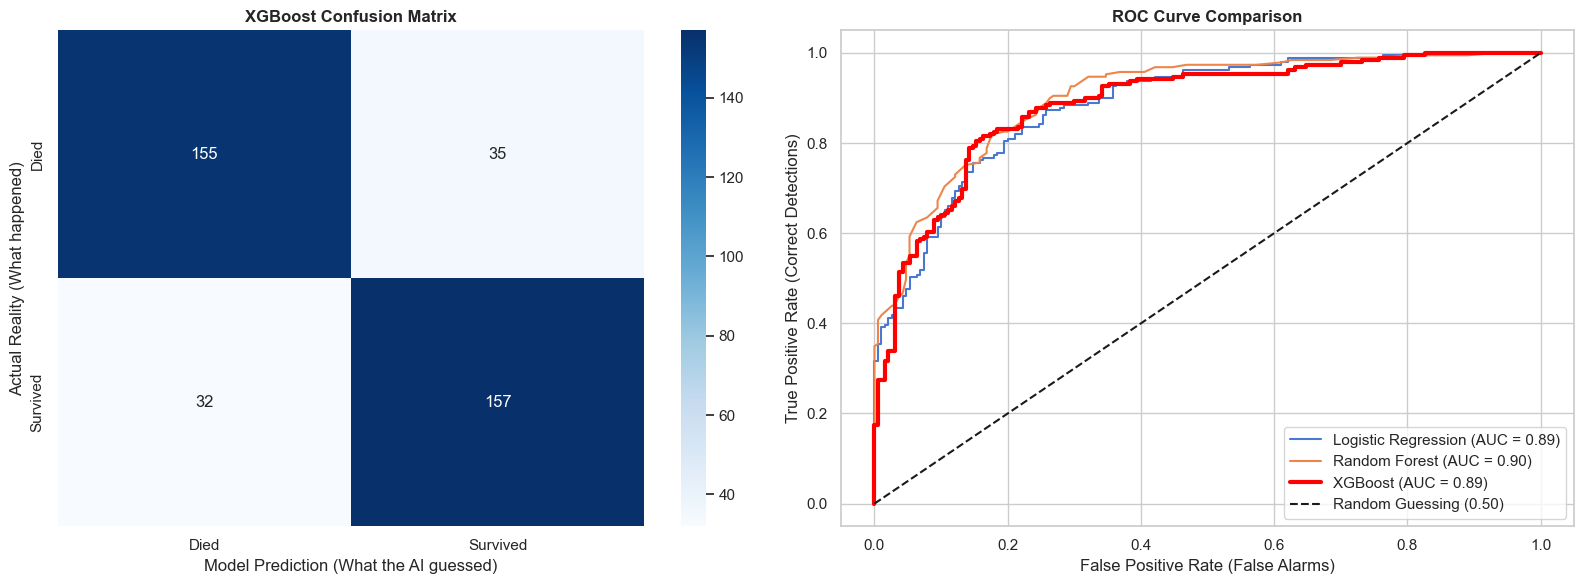

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# 1. Print Precision, Recall, and F1 Score for XGBoost
y_pred_xgb = xgb.predict(X_test)
print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Died', 'Survived']))

# 2. Confusion Matrix for XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
axes[0].set_title('XGBoost Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual Reality (What happened)')
axes[0].set_xlabel('Model Prediction (What the AI guessed)')

# 3. ROC-AUC Curve
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

axes[1].plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc(fpr_log, tpr_log):.2f})')
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})', linewidth=3, color='red')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guessing (0.50)')

axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].set_xlabel('False Positive Rate (False Alarms)')
axes[1].set_ylabel('True Positive Rate (Correct Detections)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Step 8: Survival Analysis
Instead of just asking *if* a patient survives, we use `lifelines` to ask *when*.
- **Kaplan-Meier Curve:** Visualizes the probability of survival over time (Stage I vs Stage IV).
- **Cox Proportional Hazards:** Calculates the precise 'Hazard Ratio' to show exactly how dangerous a specific feature is (e.g., how much does age increase risk?).
*Note: In survival analysis, the 'event' we track is death. So we flip our 'Survived' column: 1 means they died (event occurred), 0 means they survived (censored).*

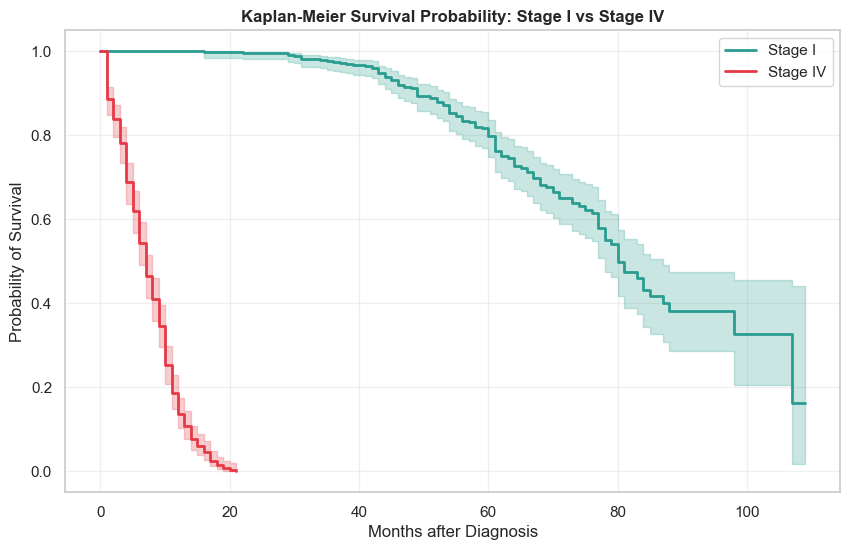


--- Cox Proportional Hazards Summary ---


<lifelines.CoxPHFitter: fitted with 1500 total observations, 553 right-censored observations>
             duration col = 'Survival_Months'
                event col = 'Event_Death'
      baseline estimation = breslow
   number of observations = 1500
number of events observed = 947
   partial log-likelihood = -5273.58
         time fit was run = 2026-05-21 11:39:40 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
Age            0.00      1.00      0.00           -0.00            0.01                1.00                1.01
Cancer_Stage   2.25      9.46      0.07            2.11            2.39                8.21               10.90
Tumor_Size_cm -0.03      0.97      0.02           -0.07            0.01                0.93                1.01

               cmp to     z      p  -log2(p)
covariate                                   
Age              0.00  0.62   0.53      0.91
Cancer_Stage     0.00 31.08 <0.005    702.00
Tumor_Size_cm    0.00 -1.49   0.14      2.86
---
Concordance = 0.87
Partial AIC = 10553.16
log-likelihood ratio test = 2035.35 on 3 df
-log2(p) of ll-ratio test = inf

In [8]:
from lifelines import KaplanMeierFitter, CoxPHFitter

# Create the 'Event' column (1 = Died, 0 = Survived)
df['Event_Death'] = 1 - df['Survived']

# 1. Kaplan-Meier Curves by Cancer Stage
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

# Stage I
stage_1 = (df['Cancer_Stage'] == 1)
kmf.fit(durations=df['Survival_Months'][stage_1], event_observed=df['Event_Death'][stage_1], label='Stage I')
kmf.plot_survival_function(color='#2a9d8f', linewidth=2)

# Stage IV
stage_4 = (df['Cancer_Stage'] == 4)
kmf.fit(durations=df['Survival_Months'][stage_4], event_observed=df['Event_Death'][stage_4], label='Stage IV')
kmf.plot_survival_function(color='#e63946', linewidth=2)

plt.title('Kaplan-Meier Survival Probability: Stage I vs Stage IV', fontweight='bold')
plt.ylabel('Probability of Survival')
plt.xlabel('Months after Diagnosis')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Cox Proportional Hazards Model
cph = CoxPHFitter()
# We select a few key numerical features to analyze their hazard ratios
df_cox = df[['Age', 'Cancer_Stage', 'Tumor_Size_cm', 'Survival_Months', 'Event_Death']]
cph.fit(df_cox, duration_col='Survival_Months', event_col='Event_Death')

print("\n--- Cox Proportional Hazards Summary ---")
cph.print_summary()

## Step 9: Model Explainability (SHAP)
Medical AI cannot be a "black box". We must know exactly *why* our model made a specific prediction.
We use **SHAP** to calculate the exact impact of every single feature. We will explain our **Random Forest** model here:
1. **Summary Beeswarm Plot:** Shows which features matter most across the *entire* patient population.
2. **Waterfall Plot:** Breaks down the exact reasoning for a *single, individual* patient.

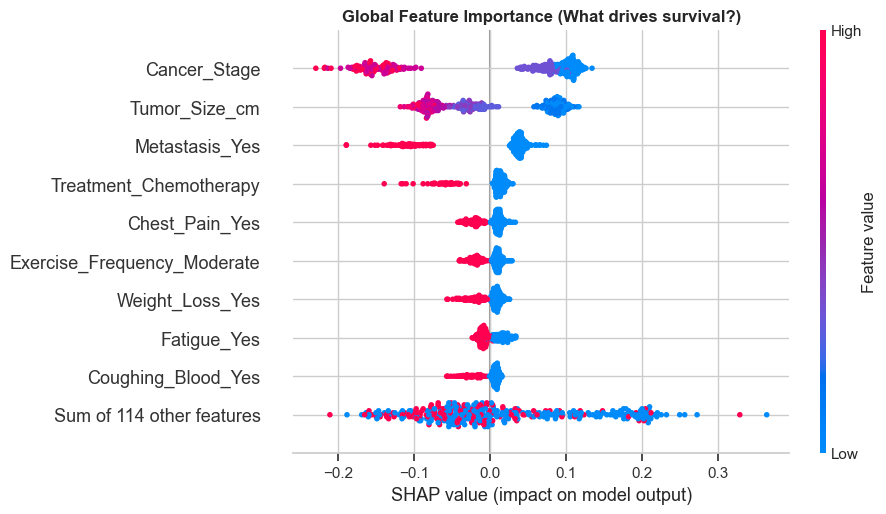

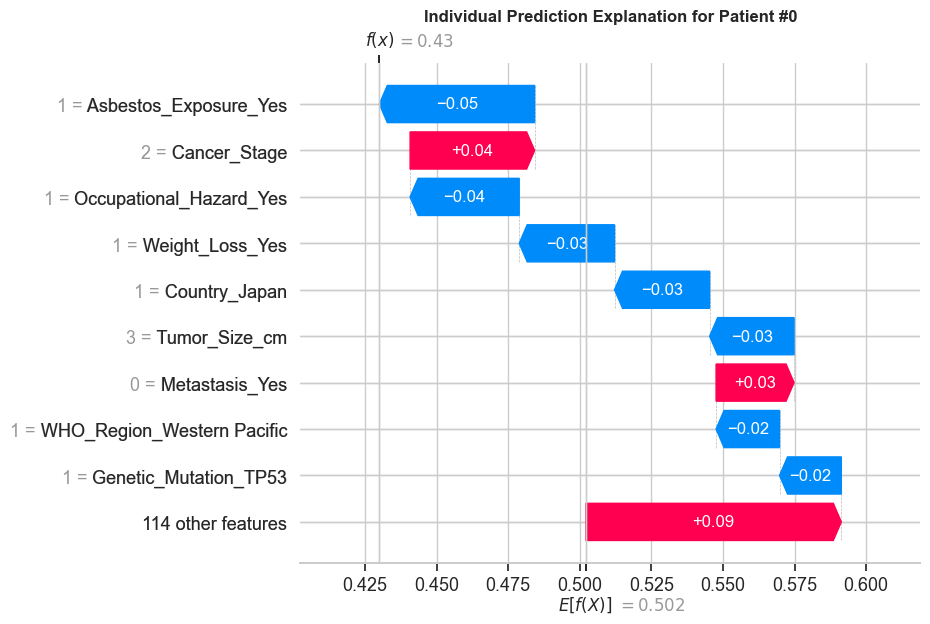

In [9]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer for our Random Forest model
explainer = shap.TreeExplainer(rf)
# Random forest outputs 2 probabilities (die, survive). We want the SHAP values for class 1 (Survived)
shap_values = explainer(X_test)[..., 1]

# 2. Global Explainability: SHAP Summary (Beeswarm) Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title('Global Feature Importance (What drives survival?)', fontweight='bold')
plt.show()

# 3. Local Explainability: Waterfall Plot for Patient #0 in the test set
# Let's see exactly why this specific patient got their prediction
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_values[0], show=False)
plt.title(f'Individual Prediction Explanation for Patient #0', fontweight='bold')
plt.show()

## Step 10: Exporting Models for Deployment
We are finished with our analysis! Now, we must save our trained Random Forest model to a physical file so our Gradio Web App can load it later. We also save the exact column names the model was trained on, so the web app knows how to format the user's input.

In [ ]:
import joblib

# 1. Save the model and the expected columns into a dictionary
model_data = {
    'model': rf,
    'expected_columns': list(X.columns)
}

# 2. Export it to the outputs folder
joblib.dump(model_data, '../outputs/lung_cancer_rf_model.pkl')
print("Model successfully exported to outputs/lung_cancer_rf_model.pkl")